# Assignment 8: Logistic Regression vs. Random Forest vs. XGBoost

Compare three classification models, Logistic Regression, Random Forest, and Gradient Boosting (XGBoost), uisng the Pima Indians Diabetes dataset, and determine the best-performing model with a short technical explanation.

In [25]:
# 1. Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Load the Dataset

In [26]:
# 2. Load the Dataset
data = fetch_openml(
    name="diabetes",
    version=1,
    as_frame=True,
    parser="auto"
)

X = data.data

# 0 = No Diabetes, 1 = Diabetes
y = (data.target == "tested_positive").astype(int)
y = pd.Series(y.values, name="target")

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nClass balance:")
print(y.value_counts(normalize=True).rename({0: "No Diabetes", 1: "Diabetes"}))

Features shape: (768, 8)
Target shape: (768,)

Class balance:
target
No Diabetes    0.651042
Diabetes       0.348958
Name: proportion, dtype: float64


In [27]:
# 3. Split the data into Training and Testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)

Training features: (614, 8)
Testing features : (154, 8)


## Feature Scaling

In [28]:
# 4. Scale features (Logistic Regression only)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train the Three Models

### 1. Logistic Regression -- the interpretable linear baseline

In [29]:
# 5. Train Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_reg_train_predictions = log_reg.predict(X_train_scaled)
log_reg_test_predictions = log_reg.predict(X_test_scaled)
log_reg_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("LOGISTIC REGRESSION")
print(f"Training Accuracy: {accuracy_score(y_train, log_reg_train_predictions):.4f}")
print(f"Testing Accuracy : {accuracy_score(y_test, log_reg_test_predictions):.4f}")

LOGISTIC REGRESSION
Training Accuracy: 0.7915
Testing Accuracy : 0.7143


### 2. Random Forest: bagging, many trees voting in parallel

In [30]:
# 6. Train Random Forest
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True
)
forest_model.fit(X_train, y_train)

forest_train_predictions = forest_model.predict(X_train)
forest_test_predictions = forest_model.predict(X_test)
forest_test_proba = forest_model.predict_proba(X_test)[:, 1]

print("RANDOM FOREST")
print(f"Training Accuracy: {accuracy_score(y_train, forest_train_predictions):.4f}")
print(f"Testing Accuracy : {accuracy_score(y_test, forest_test_predictions):.4f}")
print(f"Out-of-Bag (OOB) Score: {forest_model.oob_score_:.4f}")

RANDOM FOREST
Training Accuracy: 1.0000
Testing Accuracy : 0.7727
Out-of-Bag (OOB) Score: 0.7524


### 3. XGBoost: boosting, trees built sequentially on the residuals

First train a baseline XGBoost model with reasonable default hyperparameters, then use `RandomizedSearchCV` to search `learning_rate`, `max_depth`, `min_child_weight`, `subsample`, and `colsample_bytree` for a better-generalizing configuration. `GridSearchCV` would test every combination exhaustively.

In [31]:
# 7. Train a baseline XGBoost model
xgb_baseline = XGBClassifier(
    objective="binary:logistic",
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)
xgb_baseline.fit(X_train, y_train)

xgb_base_train_predictions = xgb_baseline.predict(X_train)
xgb_base_test_predictions = xgb_baseline.predict(X_test)
xgb_base_test_proba = xgb_baseline.predict_proba(X_test)[:, 1]

print("XGBOOST (BASELINE)")
print(f"Training Accuracy: {accuracy_score(y_train, xgb_base_train_predictions):.4f}")
print(f"Testing Accuracy : {accuracy_score(y_test, xgb_base_test_predictions):.4f}")

XGBOOST (BASELINE)
Training Accuracy: 0.9821
Testing Accuracy : 0.7792


In [32]:
# 8. Tune XGBoost with RandomizedSearchCV
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "n_estimators": [100, 200, 300]
}

xgb_base_for_search = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    eval_metric="logloss"
)

random_search = RandomizedSearchCV(
    estimator=xgb_base_for_search,
    param_distributions=param_grid,
    n_iter=25,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

xgb_tuned = random_search.best_estimator_
xgb_tuned_train_predictions = xgb_tuned.predict(X_train)
xgb_tuned_test_predictions = xgb_tuned.predict(X_test)
xgb_tuned_test_proba = xgb_tuned.predict_proba(X_test)[:, 1]

print("Best Hyperparameters Found:")
print(random_search.best_params_)

print("\nXGBOOST (TUNED)")
print(f"Training Accuracy: {accuracy_score(y_train, xgb_tuned_train_predictions):.4f}")
print(f"Testing Accuracy : {accuracy_score(y_test, xgb_tuned_test_predictions):.4f}")

Best Hyperparameters Found:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

XGBOOST (TUNED)
Training Accuracy: 0.8339
Testing Accuracy : 0.7468


## Compare Performance

Accuracy alone can be misleading here since roughly 65% of patients test negative for diabetes, so a model could reach ~65% accuracy just by always predicting "No Diabetes." Precision, Recall, F1-Score, and ROC-AUC give a fuller picture of how well each model separates the two classes.

In [33]:
# 9. Compare Performance -- Logistic Regression vs Random Forest vs XGBoost
models = {
    "Logistic Regression": (log_reg, log_reg_test_predictions, log_reg_test_proba),
    "Random Forest": (forest_model, forest_test_predictions, forest_test_proba),
    "XGBoost (Baseline)": (xgb_baseline, xgb_base_test_predictions, xgb_base_test_proba),
    "XGBoost (Tuned)": (xgb_tuned, xgb_tuned_test_predictions, xgb_tuned_test_proba),
}

model_names, accuracy_list, precision_list = [], [], []
recall_list, f1_list, roc_auc_list = [], [], []

for name, (model, predictions, proba) in models.items():
    print("=" * 60)
    print(f"MODEL: {name}")
    print("=" * 60)

    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, zero_division=0)
    rec = recall_score(y_test, predictions, zero_division=0)
    f1 = f1_score(y_test, predictions, zero_division=0)
    auc = roc_auc_score(y_test, proba)

    model_names.append(name)
    accuracy_list.append(acc)
    precision_list.append(prec)
    recall_list.append(rec)
    f1_list.append(f1)
    roc_auc_list.append(auc)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print()

    print(classification_report(
        y_test,
        predictions,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    ))

comparison_table = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_list,
    "Precision": precision_list,
    "Recall": recall_list,
    "F1-Score": f1_list,
    "ROC-AUC": roc_auc_list
}).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

display(comparison_table)

MODEL: Logistic Regression
Accuracy : 0.7143
Precision: 0.6087
Recall   : 0.5185
F1-Score : 0.5600
ROC-AUC  : 0.8230

              precision    recall  f1-score   support

 No Diabetes       0.76      0.82      0.79       100
    Diabetes       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154

MODEL: Random Forest
Accuracy : 0.7727
Precision: 0.7111
Recall   : 0.5926
F1-Score : 0.6465
ROC-AUC  : 0.8148

              precision    recall  f1-score   support

 No Diabetes       0.80      0.87      0.83       100
    Diabetes       0.71      0.59      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154

MODEL: XGBoost (Baseline)
Accuracy : 0.7792
Precision: 0.7000
Recall   : 0.6481
F1-Score : 0.6731
ROC-AUC  : 0.8244


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost (Baseline),0.779221,0.700000,0.648148,0.673077,0.824444
1,Logistic Regression,0.714286,0.608696,0.518519,0.560000,0.822963
2,XGBoost (Tuned),0.746753,0.682927,0.518519,0.589474,0.820185
3,Random Forest,0.772727,0.711111,0.592593,0.646465,0.814815


## Compare Confusion Matrices

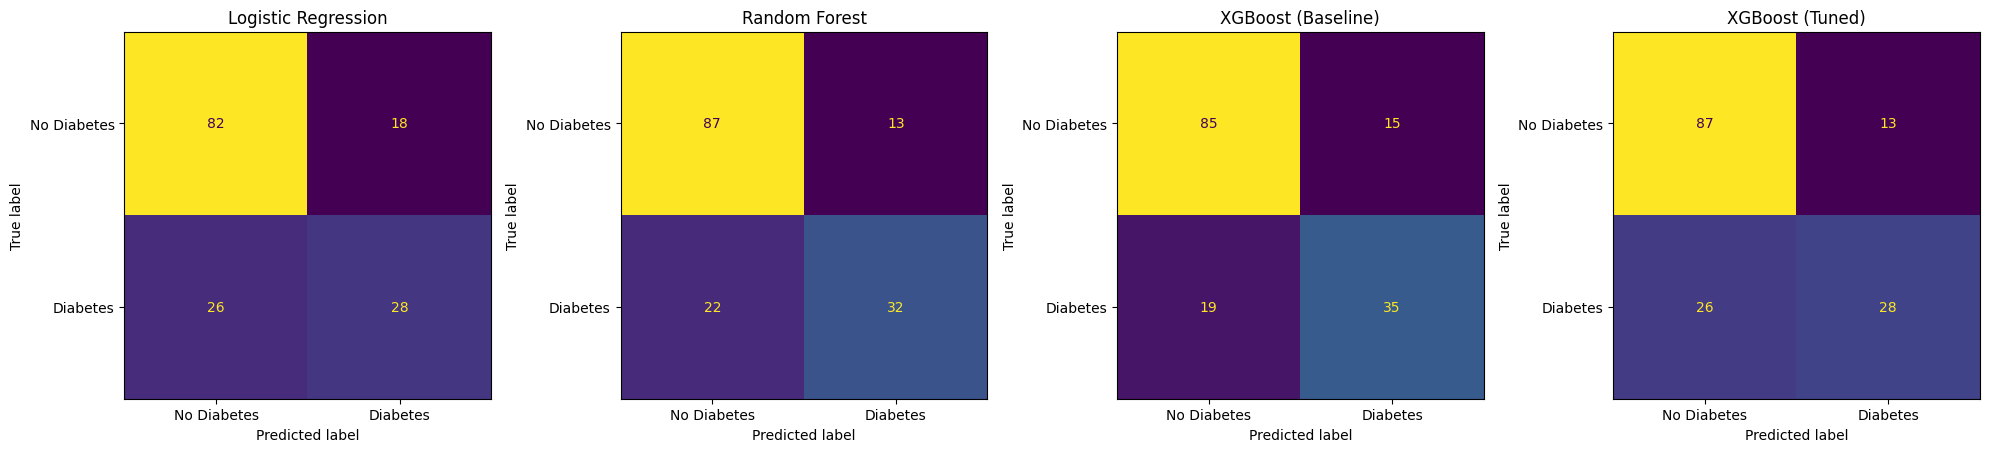

In [34]:
# 10. Compare Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, (model, predictions, proba)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Diabetes", "Diabetes"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Compare ROC Curves

The ROC curve plots the True Positive Rate against the False Positive Rate across every possible classification threshold, and ROC-AUC summarizes it in a single number: the probability that the model ranks a randomly chosen positive case (diabetic) above a randomly chosen negative case. It's a threshold-independent way to compare models, which matters here since we never tuned the 0.5 default decision threshold.

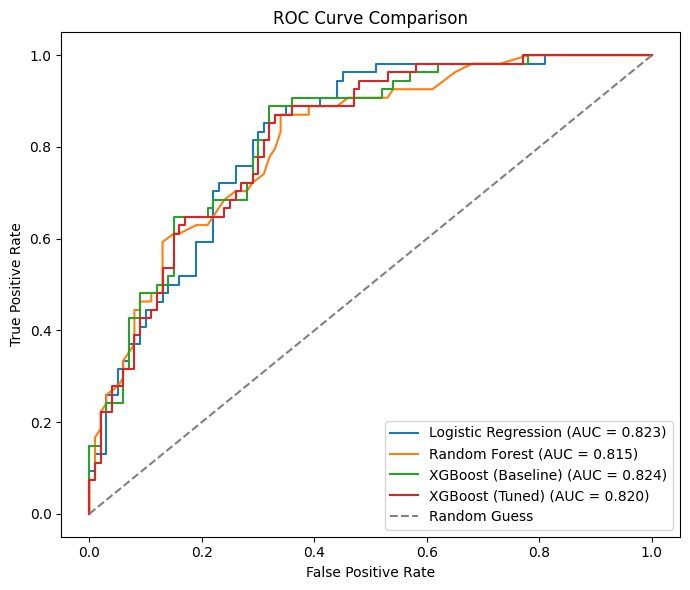

In [35]:
# 11. Compare ROC Curves
plt.figure(figsize=(7, 6))

for name, (model, predictions, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Feature Importance / Coefficients

Each model explains "importance" differently: Logistic Regression via the magnitude of its (standardized) coefficients, Random Forest and XGBoost via how much each feature reduces impurity across their trees.

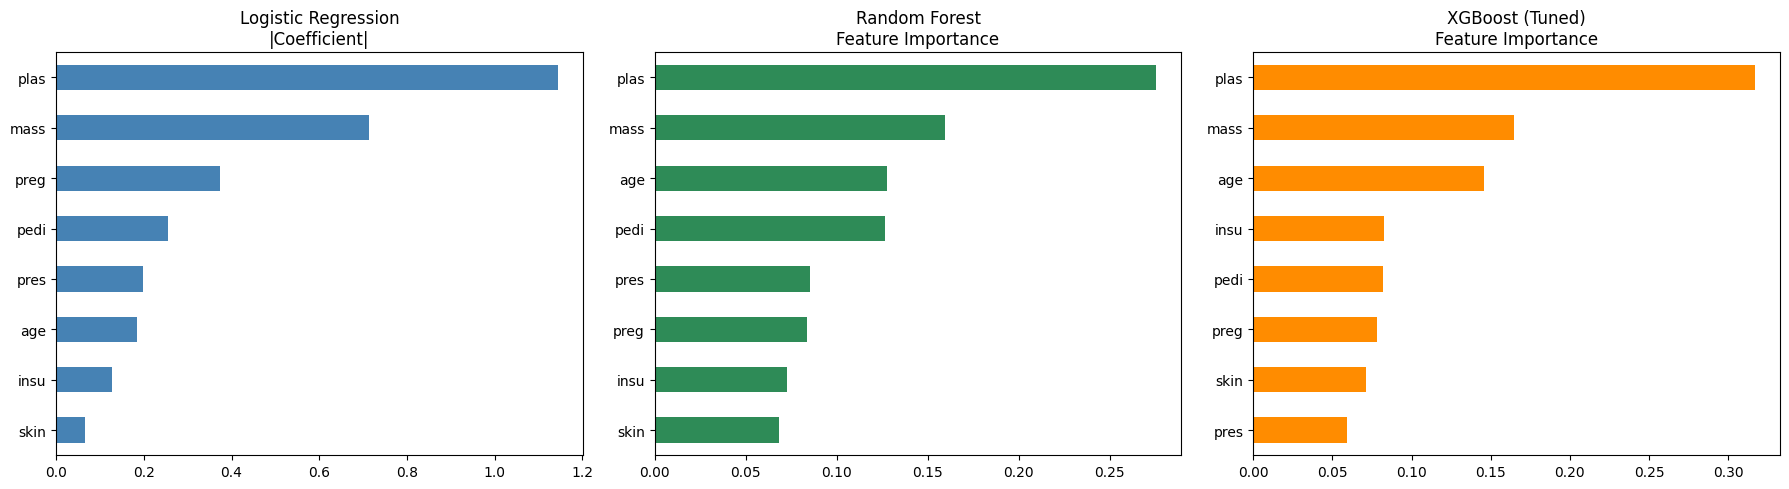

In [36]:
# 12. Feature Importance Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

log_reg_importance = pd.Series(
    np.abs(log_reg.coef_[0]), index=X.columns
).sort_values()
log_reg_importance.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Logistic Regression\n|Coefficient|")

forest_importance = pd.Series(
    forest_model.feature_importances_, index=X.columns
).sort_values()
forest_importance.plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("Random Forest\nFeature Importance")

xgb_importance = pd.Series(
    xgb_tuned.feature_importances_, index=X.columns
).sort_values()
xgb_importance.plot(kind="barh", ax=axes[2], color="darkorange")
axes[2].set_title("XGBoost (Tuned)\nFeature Importance")

plt.tight_layout()
plt.show()

## Comparison and Interpretation

### Performance

| Model | Train Acc | Test Acc | Precision | Recall | F1-Score | ROC-AUC |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.7915 | 0.7143 | 0.6087 | 0.5185 | 0.5600 | 0.8230 |
| Random Forest | 1.0000 | 0.7727 | 0.7111 | 0.5926 | 0.6465 | 0.8148 |
| **XGBoost (Baseline)** | 0.9821 | **0.7792** | **0.7000** | **0.6481** | **0.6731** | **0.8244** |
| XGBoost (Tuned) | 0.8339 | 0.7468 | 0.6829 | 0.5185 | 0.5895 | 0.8202 |

**XGBoost (Baseline) is the best performer overall** - it has the highest Test Accuracy, Precision, Recall, F1-Score, and ROC-AUC of the four models. The tuned XGBoost model, selected by 5-fold cross-validated `RandomizedSearchCV`, actually performs worse on the held-out test set than the untuned baseline.

### Why Boosting Beats Bagging and Logistic Regression Here

1. **Sequential error correction.** Random Forest's trees are built independently and vote by majority. XGBoost's trees are built one after another, each one correcting the previous trees' errors, which is likely why it has the highest Recall (0.6481) of the four models, ahead of Random Forest (0.5926) and Logistic Regression (0.5185).
2. **Non-linear interactions Logistic Regression can't capture.** Logistic Regression fits one linear boundary, while both tree ensembles can carve out non-linear regions (e.g. high glucose *and* high BMI), explaining why they beat it on every metric except ROC-AUC, where it's still close (0.8230 vs XGBoost's 0.8244).

### Why the Tuned Model Lost to the Baseline

`RandomizedSearchCV` picked `learning_rate=0.01` with only 200 trees, too few to fully converge at that rate (Training Accuracy 0.8339 vs the baseline's 0.9821). With just 614 training rows split five ways for cross-validation, the search's internal ranking is noisy, so it picked a config that overfit to its own CV folds rather than the actual test set. That's a known risk of tuning on small datasets, not a bug in the code.

### Overfitting Is Still Present, Even in the Winner

Random Forest hits 100% Training Accuracy and XGBoost (Baseline) hits 98.21%, both dropping to the high 70s on test, so both are still overfitting, just less than the single Decision Tree from Assignment 7 (100% train / 72.73% test). Random Forest's Out-of-Bag score (0.7524) backs up its test accuracy without needing a separate validation split.

### Conclusion

XGBoost (Baseline) wins on every test metric, so it's the one I'd pick. Logistic Regression's coefficients would be easier to explain if interpretability mattered more here, but for this assignment XGBoost (Baseline) is the clear winner.
